* **nombre**: Marcos Bianchi
* **padrón**: 108921

## 1. Implemente un perceptrón simple que aprenda la función lógica AND y la función lógica OR, de 2 y de 4 entradas. Muestre la evolución del error durante el entrenamiento. Para el caso de 2 dimensiones, grafique la recta discriminadora y todos los vectores de entrada de la red.

In [85]:
import matplotlib.pyplot as plt
import numpy as np


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, errors)
    plt.title(f"Perceptron's classification error per epoch for an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.xticks(xs)
    plt.grid(True)
    plt.show()


def plot_weights(ws: list[tuple[float, float, float]], gate: str):
    points = [(-1, -1), (-1, 1), (1, -1), (1, 1)]

    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    fig, axes = plt.subplots(1, len(ws), figsize=(6 * len(ws), 6), squeeze=False)

    for ax, (W, B) in zip(axes[0], ws):
        Z = W[0] * xx + W[1] * yy + B
        Z = np.sign(Z)

        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.3, colors=["#ffcccc", "#ccccff"])
        ax.contour(xx, yy, Z, levels=[0], colors="blue")

        xs, ys = zip(*points)
        ax.scatter(xs, ys, color="red", edgecolor="black", zorder=5, label="Points")

        ax.set_title(f"weights: ({W[0].item():.2f}, {W[1].item():.2f}, {B:.2f})")

        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.grid(True)

    fig.suptitle(f"Perceptron's classification per epoch for {gate} gate")
    plt.tight_layout()
    plt.show()


SEED = 1234

$$AND(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|-1|
|-1|1|-1|
|-1|-1|-1|

In [87]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * all(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

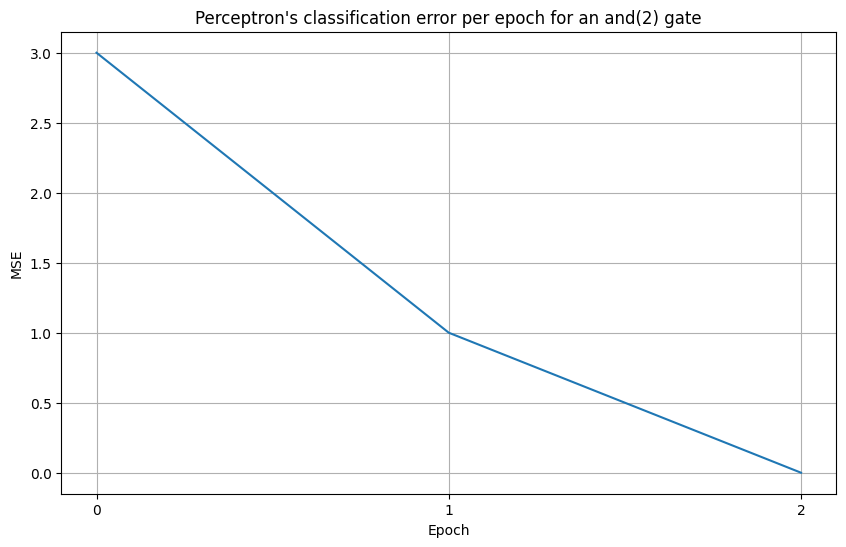

In [88]:
plot_errors(errors, "and(2)")

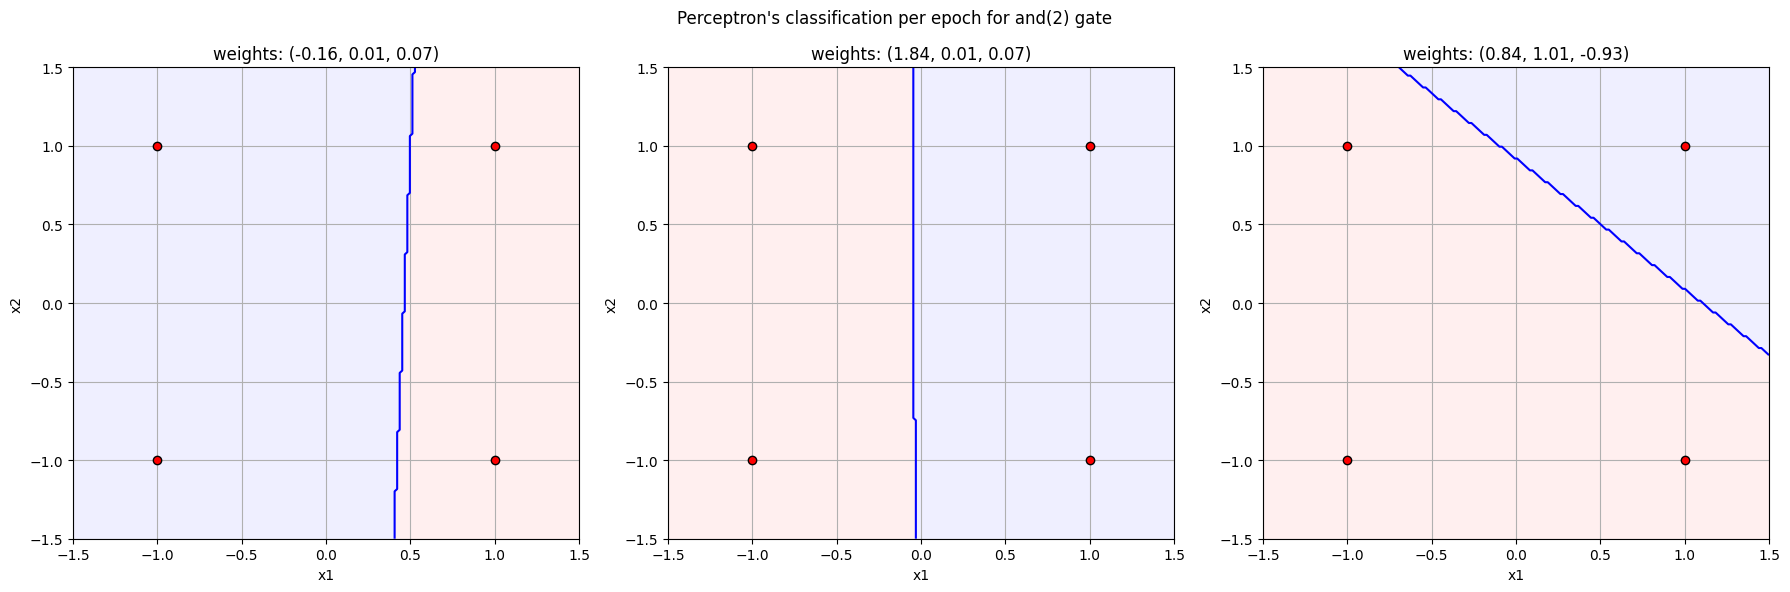

In [4]:
plot_weights(ws, "and(2)")

$$OR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [89]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(2, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * any(x == 1 for x in xs) - 1)

ws, errors = [], []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)
    ws.append((m.W.copy(), m.B))

m.train(X, Y, epoch_f=tracker)

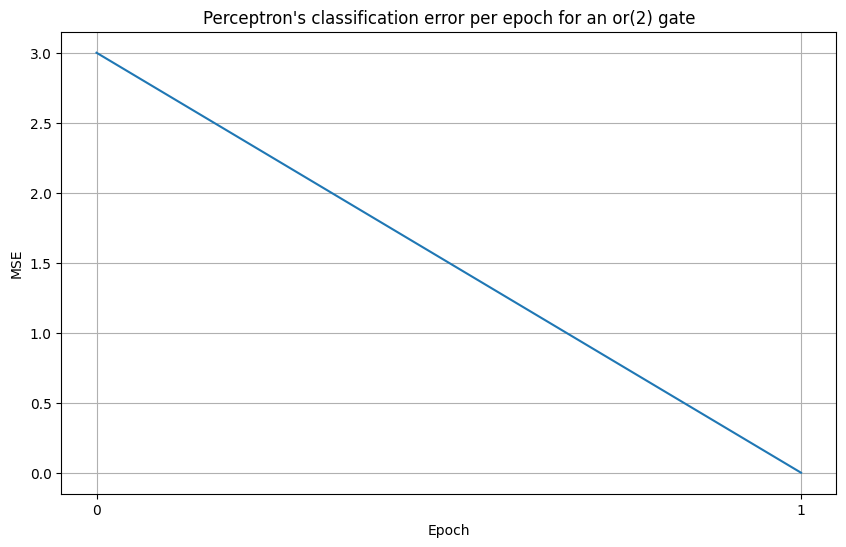

In [90]:
plot_errors(errors, "or(2)")

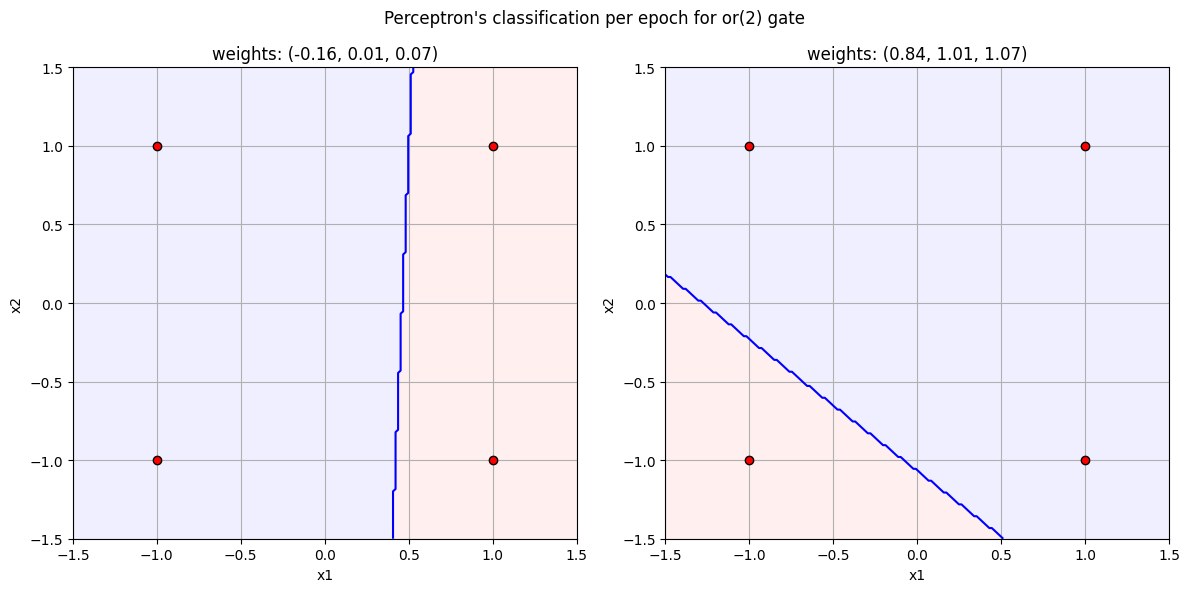

In [7]:
plot_weights(ws, "or(2)")

$$AND(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|-1|
|1|1|-1|1|-1|
|1|1|-1|-1|-1|
|1|-1|1|1|-1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|-1|
|-1|1|1|1|-1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|-1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|-1|
|-1|-1|-1|1|-1|
|-1|-1|-1|-1|-1|

In [91]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * all(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

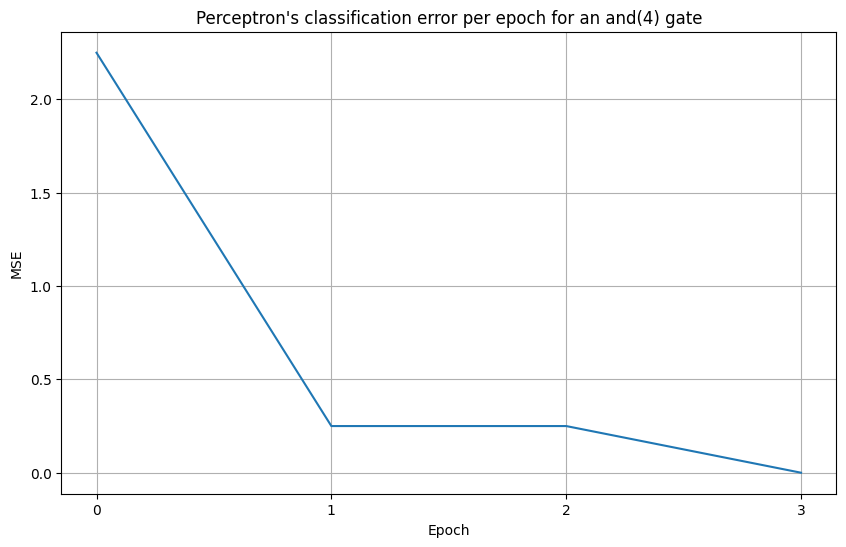

In [92]:
plot_errors(errors, "and(4)")

$$OR(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|1|
|1|1|1|-1|1|
|1|1|-1|1|1|
|1|1|-1|-1|1|
|1|-1|1|1|1|
|1|-1|1|-1|1|
|1|-1|-1|1|1|
|1|-1|-1|-1|1|
|-1|1|1|1|1|
|-1|1|1|-1|1|
|-1|1|-1|1|1|
|-1|1|-1|-1|1|
|-1|-1|1|1|1|
|-1|-1|1|-1|1|
|-1|-1|-1|1|1|
|-1|-1|-1|-1|-1|

In [93]:
from src.perceptron import Perceptron
from src.utils import truth_table
import numpy as np


m = Perceptron(4, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * any(x == 1 for x in xs) - 1)

errors = []
def tracker(m: Perceptron):
    err = m.mse(X, Y)
    errors.append(err)

m.train(X, Y, epoch_f=tracker)

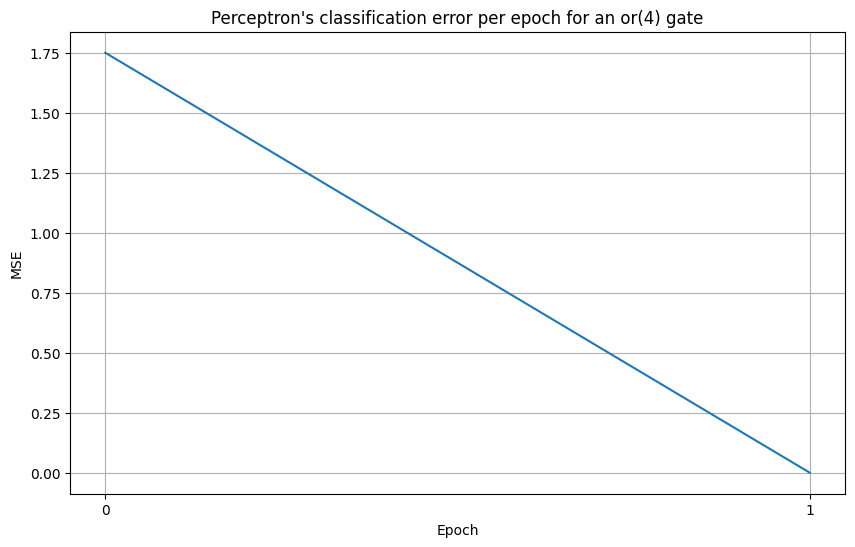

In [94]:
plot_errors(errors, "or(4)")

## 2. Determine numéricamente cómo varía la capacidad del perceptrón simple en función del número de patrones enseñados.

In [14]:
from src.perceptron import Perceptron
import matplotlib.pyplot as plt
import numpy as np


n, n_t = 20, 250
xs = np.arange(1, 4 * n + 1, 2)
ys = [Perceptron.capacity(n, n_p, n_t, seed=SEED, max_iter=100) for n_p in xs]

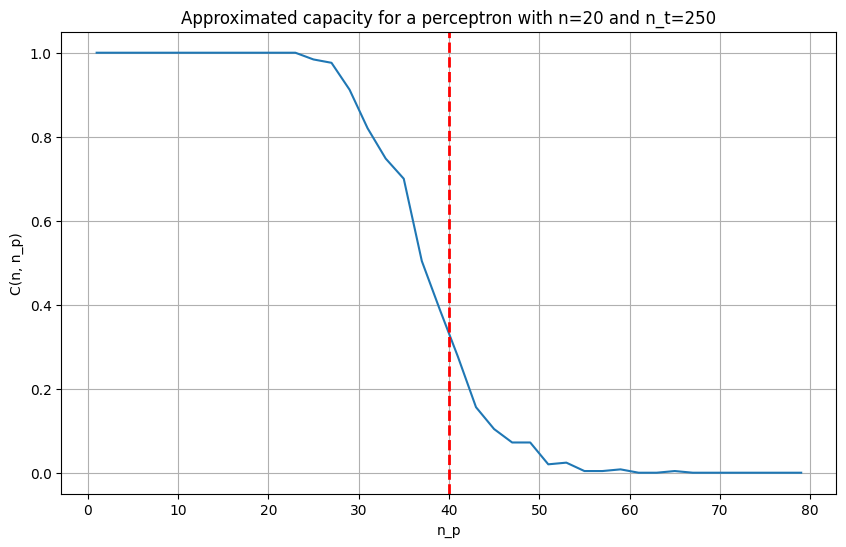

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(xs, ys)
plt.title(f"Approximated capacity for a perceptron with n={n} and n_t={n_t}")
plt.axvline(x=2 * n, color="red", linestyle="--", linewidth=2)
plt.xlabel("n_p")
plt.ylabel("C(n, n_p)")
plt.grid(True)
plt.show()

## 3. Implemente un perceptrón multicapa que aprenda la función lógica XOR de 2 y de 4 entradas (utilizando el algoritmo Backpropagation y actualizando en batch). Muestre cómo evoluciona el error durante el entrenamiento.

In [31]:
from src.layer import Dense, Tanh, Layer
from typing import Optional
from src.utils import windows
import matplotlib.pyplot as plt


def build_xor_arch(neurons: list[int]) -> list[Layer]:
    return sum(([Dense(prev, curr), Tanh(curr)] for prev, curr in windows(neurons, 2)), [])


def plot_errors(errors: list[float], gate: str):
    xs = list(range(len(errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, errors)
    plt.title(f"Multi Layer Perceptron's classification error per epoch an {gate} gate")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.show()


SEED = 1234

$$XOR(2)$$
|x1|x2|y|
|-|-|-|
|1|1|-1|
|1|-1|1|
|-1|1|1|
|-1|-1|-1|

In [32]:
from src.layer import Dense, Tanh
from src.utils import truth_table
from src.mlp import MLP


arch = build_xor_arch([2, 2, 1])
m = MLP(arch, seed=SEED)
X, Y = truth_table(2, lambda xs: 2 * (xs.count(1) % 2 == 1) - 1)

errors = []
def tracker(m: MLP):
    errors.append(m.mse(X, Y))

m.train(X, Y, lr=0.5, epoch_f=tracker)

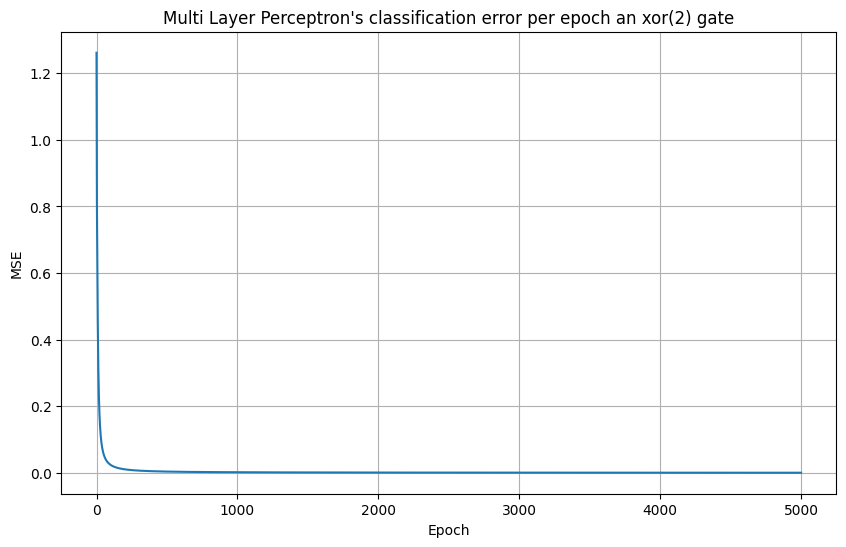

In [33]:
plot_errors(errors, "xor(2)")

$$XOR(4)$$
|x1|x2|x3|x4|y|
|-|-|-|-|-|
|1|1|1|1|-1|
|1|1|1|-1|1|
|1|1|-1|1|1|
|1|1|-1|-1|-1|
|1|-1|1|1|1|
|1|-1|1|-1|-1|
|1|-1|-1|1|-1|
|1|-1|-1|-1|1|
|-1|1|1|1|1|
|-1|1|1|-1|-1|
|-1|1|-1|1|-1|
|-1|1|-1|-1|1|
|-1|-1|1|1|-1|
|-1|-1|1|-1|1|
|-1|-1|-1|1|1|
|-1|-1|-1|-1|-1|

In [34]:
from src.layer import Dense, Tanh
from src.utils import truth_table
from src.mlp import MLP


arch = build_xor_arch([4, 4, 1])
m = MLP(arch, seed=SEED)
X, Y = truth_table(4, lambda xs: 2 * (xs.count(1) % 2 == 1) - 1)

errors = []
def tracker(m: MLP):
    errors.append(m.mse(X, Y))

m.train(X, Y, lr=0.5, epoch_f=tracker)

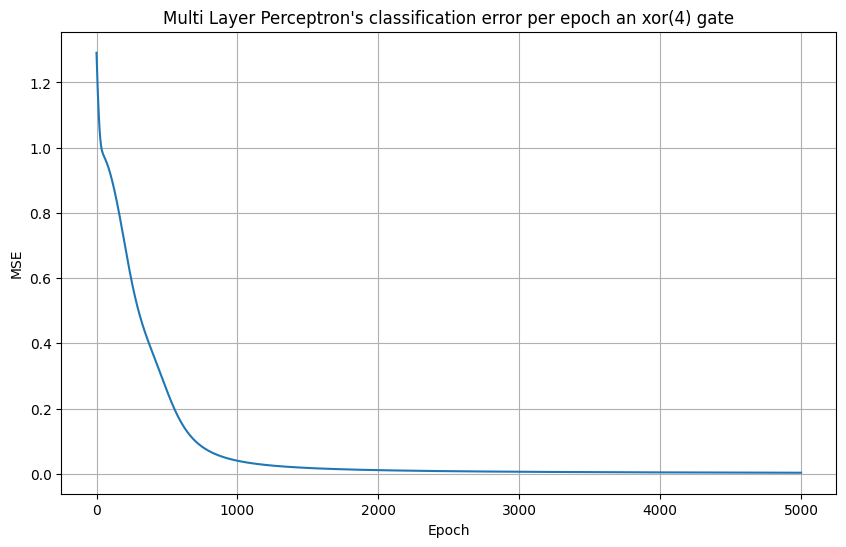

In [35]:
plot_errors(errors, "xor(4)")

## 4-a) Implemente una red con aprendizaje Backpropagation que aprenda la siguiente función: $$f(x, y, z) = sin(x) + cos(y) + z$$
## donde: x e y $\in$ [0, 2$\pi$] y z $\in$ [−1,1]. Para ello construya un conjunto de datos de entrenamiento y un conjunto de evaluación. Muestre la evolución del error de entrenamiento y de evaluación en función de las épocas de entrenamiento.

In [71]:
import numpy as np
import matplotlib.pyplot as plt


def generate_dataset(n: int, training_ratio: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    f = lambda x: np.sin(x[0]) + np.cos(x[1]) + x[2]
    rng = np.random.default_rng(seed=SEED)
    
    x = rng.uniform(0, 2 * np.pi, n)
    y = rng.uniform(0, 2 * np.pi, n)
    z = rng.uniform(-1, 1, n)

    t = int(training_ratio * n)
    
    X = np.column_stack((x, y, z))
    X_train, X_test = X[:t], X[t:]
    
    Y = np.array([f(x) for x in X]).reshape(-1, 1)
    Y_train, Y_test = Y[:t], Y[t:]

    return X_train, X_test, Y_train, Y_test


def plot_errors(train_errors: list[float], test_errors: list[float], func: str):
    xs = list(range(len(train_errors)))

    plt.figure(figsize=(10, 6))
    plt.plot(xs, train_errors, label="train")
    plt.plot(xs, test_errors, label="test")
    plt.title(f"Multi Layer Perceptron's classification error per epoch for {func}")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_preds(m: MLP, X: np.ndarray, Y: np.ndarray):
    Y_pred = m.forward(X)
    xs = np.linspace(-3, 3)

    plt.figure(figsize=(10, 6))
    plt.scatter(Y_pred, Y)
    plt.plot(xs, xs, color="red")
    plt.title("Multi Layer Perceptron's predictions vs real values")
    plt.xlabel("Predictions")
    plt.ylabel("Real Values")
    plt.grid(True)
    plt.show()

SEED = 1234


In [72]:
from src.mlp import MLP
from src.layer import Dense, Tanh


arch = [
    Dense(3, 10),
    Tanh(),
    Dense(10, 10),
    Tanh(),
    Dense(10, 1),
    Tanh(a=3.0)
]
m = MLP(arch, seed=SEED)

X_train, X_test, Y_train, Y_test = generate_dataset(100, 0.8)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.mse(X_train, Y_train))
    test_errors.append(m.mse(X_test, Y_test))

m.train(X_train, Y_train, lr=0.1, max_iter=10_000, epoch_f=tracker)

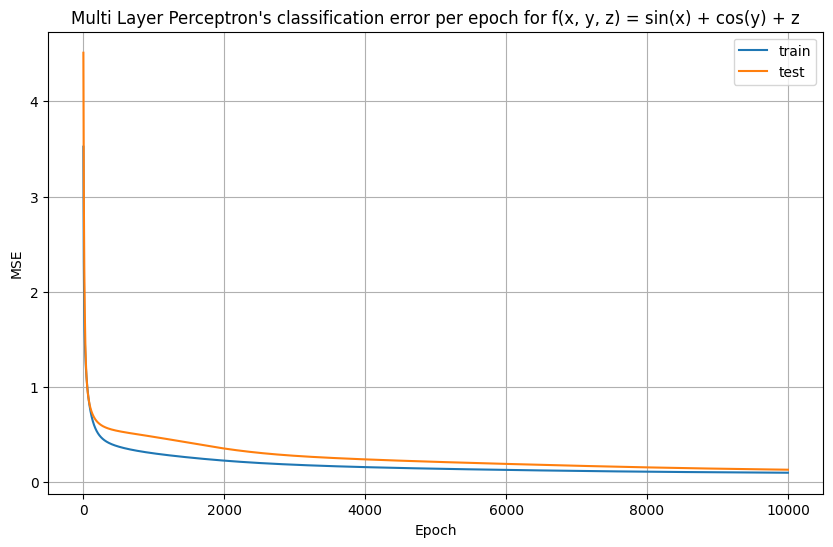

In [73]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

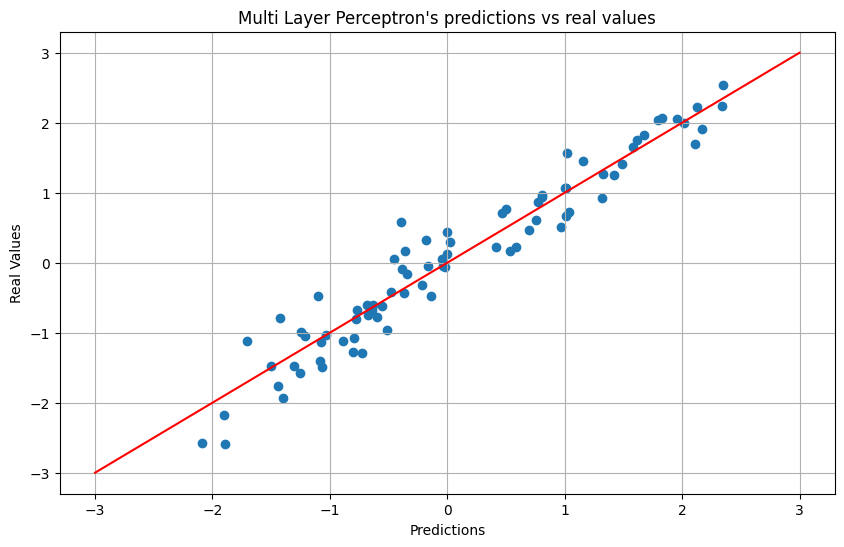

In [74]:
plot_preds(m, X_train, Y_train)

## 4-b) Estudie la evolución de los errores durante el entrenamiento de una red con una capa oculta de 30 neuronas cuando el conjunto de entrenamiento contiene 40 muestras. ¿Que ocurre si el minibatch tiene tamaño 40? ¿Y si tiene tamaño 1?

In [76]:
from src.layer import Dense, Tanh


arch = [
    Dense(3, 30),
    Tanh(),
    Dense(30, 1),
]

X_train, X_test, Y_train, Y_test = generate_dataset(40, 0.8)

In [77]:
from src.mlp import MLP


m = MLP(arch, seed=SEED)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.mse(X_train, Y_train))
    test_errors.append(m.mse(X_test, Y_test))

m.train(X_train, Y_train, lr=0.35, epoch_f=tracker)

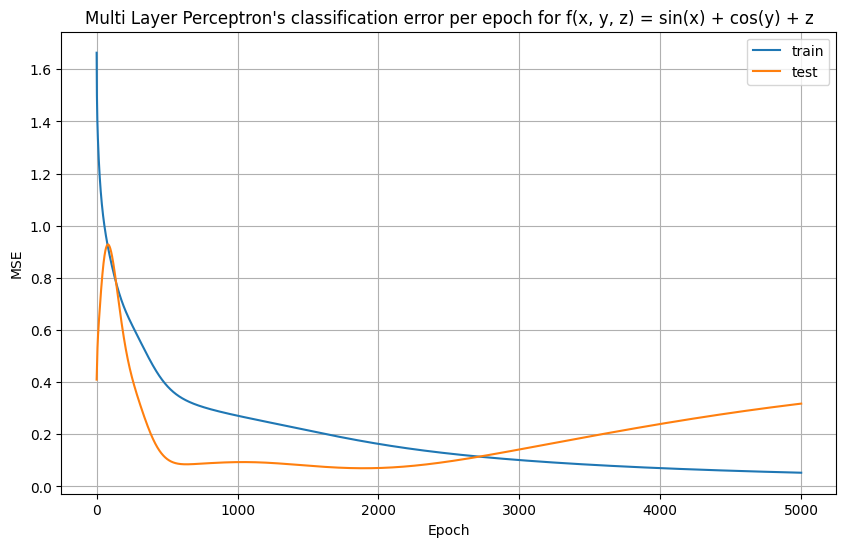

In [79]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

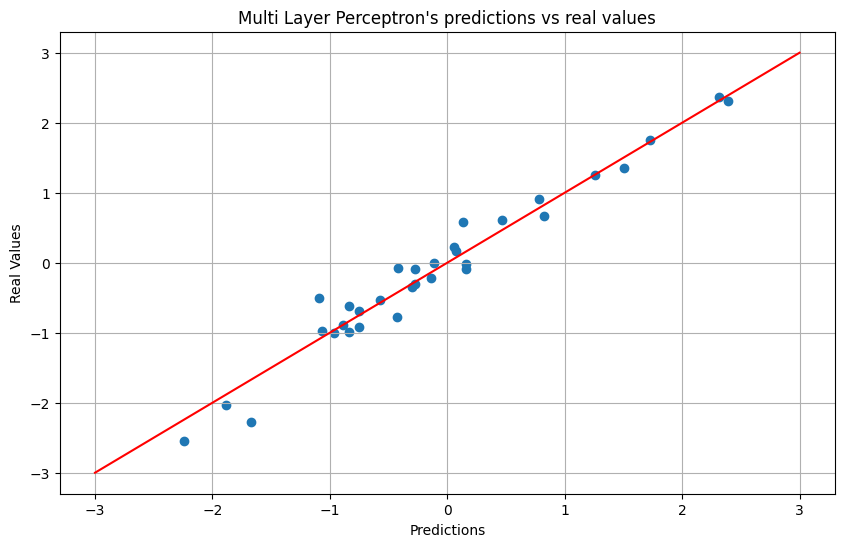

In [80]:
plot_preds(m, X_train, Y_train)

In [81]:
from src.mlp import MLP


m = MLP(arch, seed=SEED)

train_errors, test_errors = [], []
def tracker(m: MLP):
    train_errors.append(m.mse(X_train, Y_train))
    test_errors.append(m.mse(X_test, Y_test))

m.train(X_train, Y_train, batch_size=1, lr=0.01, epoch_f=tracker)

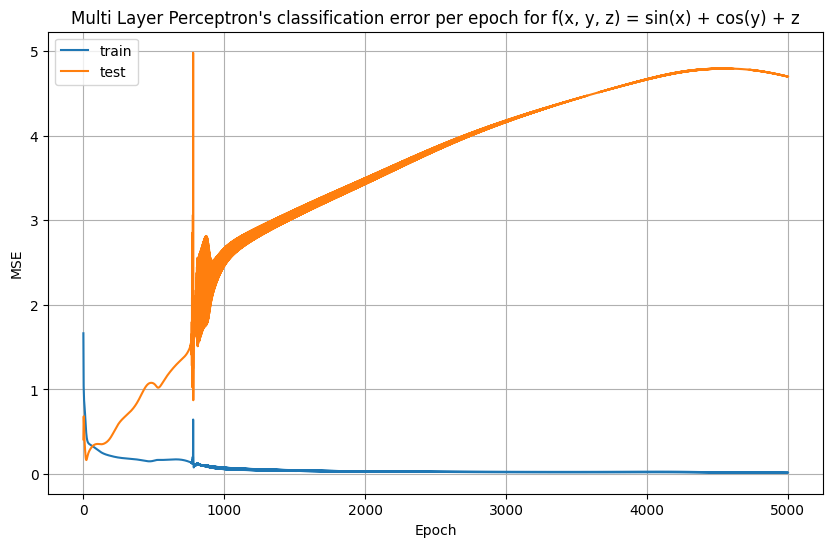

In [83]:
plot_errors(train_errors, test_errors, "f(x, y, z) = sin(x) + cos(y) + z")

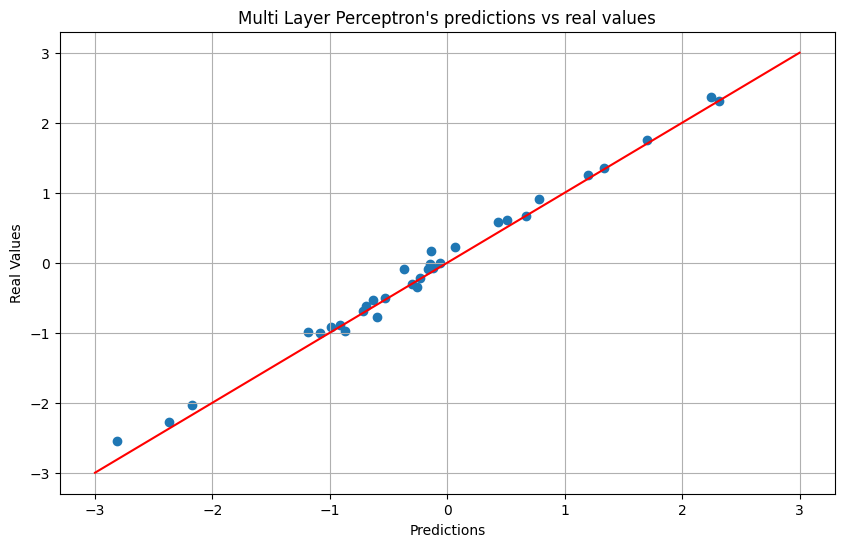

In [84]:
plot_preds(m, X_train, Y_train)

## 5. Siguiendo el trabajo de Hinton y Salakhutdinov (2006), entrene una máquina restringida de Boltzmann con imágenes de la base de datos MNIST. Muestre el error de recontruccion durante el entrenamiento, y ejemplos de cada uno de los dígitos reconstruidos.

In [1]:
from scipy.io import loadmat
from typing import Iterable
import matplotlib.pyplot as plt
import numpy as np


def get_images(path: str) -> np.ndarray:
    return loadmat(path)["data"]


def plot_images(ims: Iterable[np.ndarray], rows: int, cols: int):
    imgs = [np.reshape(im, (28, 28)) for im in ims]

    fig, axs = plt.subplots(rows, cols, figsize=(cols << 1, rows << 1))
    axs = np.array(axs).flatten()

    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


SEED = 1234

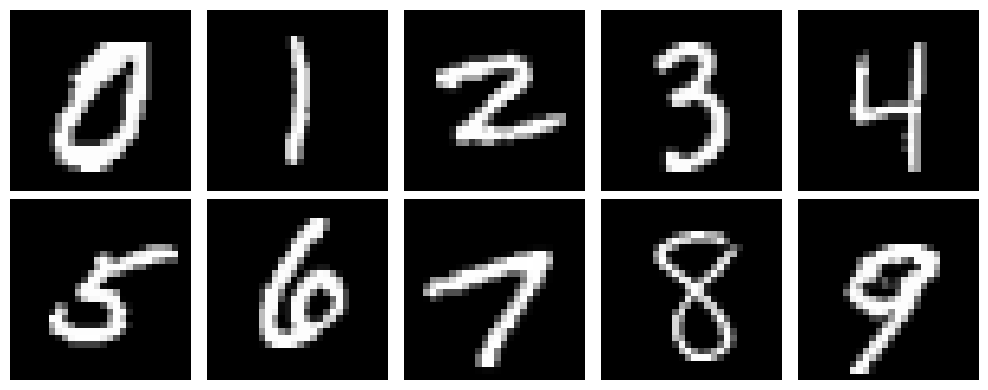

In [2]:
M_train = get_images("images/train.mat")
plot_images((M_train[i] for i in range(10, 200, 20)), 2, 5)

In [ ]:
from src.rbm import RBM

v = 784 # size of images
h = 500 # compression size

m = RBM(v, h, seed=SEED)

m.train(M_train, batch_size=20)